# 01. Library Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import distance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로드 완료")


✅ 라이브러리 로드 완료


# 02. Data Load

- 원본 데이터: `(아이엠뱅크) 2025 교육용 데이터.csv`
- 금리 데이터: `iM뱅크_금리현황_2022-2024.csv`
- 범주형 거래건수/좌수 → 수치형 변환 (구간 매핑)

In [4]:
# 데이터 로드
df   = pd.read_csv("C:\\project\\(아이엠뱅크) 2025 교육용 데이터.csv", encoding='cp949')
df_b = pd.read_csv("C:\\project\\iM뱅크_금리현황_2022-2024정상.csv")

# ── 거래건수 범주형 → 수치형 매핑 ────────────────────
count_mapping = {
    "0건": 0, "1건": 1, "2건": 2,
    "2건초과 5건이하": 3.5, "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15, "20건초과 30건이하": 25,
    "30건초과 40건이하": 35, "40건초과 50건이하": 45,
    "50건 초과": 55,
}
account_mapping = {
    "0개": 0, "1개": 1, "2개": 2,
    "2개초과 5개이하": 4, "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5, "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5, "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수", "스마트뱅킹거래건수", "폰뱅킹거래건수",
    "자동이체거래건수", "창구거래건수", "ATM거래건수",
    "외환_수출실적거래건수", "외환_수입실적거래건수",
]
account_count_cols = [
    "요구불예금좌수", "거치식예금좌수", "적립식예금좌수",
    "수익증권좌수", "신탁좌수", "퇴직연금좌수",
    "여신_운전자금대출좌수", "여신_시설자금대출좌수", "신용카드개수",
]

for col in channel_count_cols:
    if col in df.columns: df[col] = df[col].map(count_mapping)
for col in account_count_cols:
    if col in df.columns: df[col] = df[col].map(account_mapping)

print(f"✅ 데이터 로드 완료 | shape: {df.shape}")


✅ 데이터 로드 완료 | shape: (347299, 45)


# 03. Feature Engineering

## 3-1. 변수 그룹화 및 파생변수 생성

| 그룹 | 변수 | 근거 |
|------|------|------|
| 자산성(Asset) | 총예금잔액, 자산관리잔액 | 법인 현금 동원력·재무 안정성 |
| 여신(Debt) | 총대출잔액 | 운전자금(운영)·시설자금(투자) 구분 |
| 거래(Transaction) | 총디지털거래액, 총오프라인거래액, 총카드소비 | 채널 선호도·활동성 |
| 외환(Global) | 총외환실적 | 수출입 실적 → 공단 지역 특성 보간 |

## 3-2. 외부 금리 데이터 병합 → 예대마진(y) 산출
- 예대마진 = 대출이자 − 예금이자
- NaN(총자산=0, 휴면기업) 행 제거

## 3-3. 결측치 처리
- 세종특별자치시: 시군구 → '세종시' 자동 보정
- 나머지 주소 결측: '미상' 일괄 치환

In [5]:
# ── 3-1. 변수 그룹 정의 ──────────────────────────────
deposit_bal_cols  = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]
product_bal_cols  = ["수익증권잔액", "신탁잔액"]          # 퇴직연금 corr=0.92 → 다중공선성 제거
deposit_cnt_cols  = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]
product_cnt_cols  = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]
flow_cols         = ["요구불입금금액", "요구불출금금액"]
loan_bal_cols     = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]
loan_cnt_cols     = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
rjfo_total        = ['인터넷뱅킹거래금액', '폰뱅킹거래금액', '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital      = ['인터넷뱅킹거래금액', '폰뱅킹거래금액', '스마트뱅킹거래금액']
rjfo_offline      = ['창구거래금액', 'ATM거래금액']
rjfo_card_total   = ['신용카드사용금액', '체크카드사용금액']
dhlghks           = ['외환_수출실적금액', '외환_수입실적금액']

# ── 3-2. 파생변수 생성 ────────────────────────────────
df['총예금잔액']      = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액']    = df[product_bal_cols].sum(axis=1)
df['총대출잔액']      = df[loan_bal_cols].sum(axis=1)
df['총예금좌수']      = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수']      = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']    = df[product_cnt_cols].sum(axis=1)
df['총요구불입출금']  = df[flow_cols].sum(axis=1)
df['전체거래액']      = df[rjfo_total].sum(axis=1)
df['총디지털거래액']  = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비']      = df[rjfo_card_total].sum(axis=1)
df['총외환실적']      = df[dhlghks].sum(axis=1)

# ── 3-3. 금리 데이터 병합 & 예대마진 산출 ─────────────
df_b_subset = df_b[['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']]
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')

df2['총자산']   = df2['총예금잔액'] + df2['총대출잔액']
df2['예금이자'] = df2['총예금잔액'] * df2['평균예금금리(%)'] * 0.01
df2['대출이자'] = df2['총대출잔액'] * df2['평균대출금리(%)'] * 0.01
df2['예대마진'] = df2['대출이자'] - df2['예금이자']

# ── 3-4. 지리 결측치 처리 ────────────────────────────
# 세종특별자치시: 단층제 행정구역이므로 시군구 Null → '세종시'로 보정
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'
df2['사업장_시도']   = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# ── 3-5. 예대마진 NaN 제거 (총자산=0, 휴면기업) ─────────
df2 = df2[df2['예대마진'].notnull()].copy()

print(f"✅ 전처리 완료 | shape: {df2.shape}")
print(f"   예대마진 결측: {df2['예대마진'].isnull().sum()}건")
print(f"\n지역별 주요 분포:")
print(df2['사업장_시도'].value_counts().head(10))


✅ 전처리 완료 | shape: (347299, 64)
   예대마진 결측: 0건

지역별 주요 분포:
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64


# 04. 변수 선정 및 데이터 준비

## 변수 선정 근거 (누수 변수 제거 원칙)
- **제거**: 총자산, 등급, 전담여부, 개별잔액 → Target과 직접 연계된 누수(Leakage) 변수
- **제거**: 총대출좌수 → 총대출잔액과 상관계수 0.22로 낮아 대표성 부족

| 최종 선정 변수 | 역할 |
|--------------|------|
| 여신한도금액 | 기업 규모·잠재력 대변 |
| 총디지털거래액 | 인터넷+스마트+폰뱅킹 통합 활동성 |
| 총오프라인거래액 | 창구+ATM 오프라인 활동성 |
| 총카드소비 | 신용+체크카드 소비 패턴 |
| 총외환실적 | 수출+수입 외환 기여도 |
| 총예금좌수 | 거래 깊이 |
| 자동이체거래건수 | 활동 빈도 |

## 전처리 파이프라인
1. 금액 변수 `np.log1p` 로그 변환 (Right-skewed 보정)
2. `StandardScaler` 정규화 → Train/Test 분리

In [6]:
# ── 대경 데이터 추출 ──────────────────────────────────
df_dg = df2[df2['사업장_시도'].isin(['대구광역시', '경상북도'])].copy()

# ── 분석 변수 선정 ────────────────────────────────────
selected_features = [
    '여신한도금액',       # 기업 규모/잠재력
    '총디지털거래액',     # 디지털 활동성
    '총오프라인거래액',   # 오프라인 활동성
    '총카드소비',         # 소비 패턴
    '총외환실적',         # 외환 기여도
    '총예금좌수',         # 거래 깊이
    '자동이체거래건수',   # 활동 빈도
]

# ── 로그 변환 (금액성 변수 스케일 보정) ────────────────
# 금융 데이터는 소수 대기업 vs 다수 영세기업 구조로 Right-skewed
# → log1p 적용으로 스케일 격차를 합리적 수준으로 압축
money_cols = ['여신한도금액', '총디지털거래액', '총오프라인거래액', '총카드소비', '총외환실적']

X = df_dg[selected_features].copy()
y = df_dg['예대마진']

for col in money_cols:
    X[col] = np.log1p(X[col])

# ── Train/Test 분리 & StandardScaler ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

print(f"✅ 피처 개수    : {X_train_scaled.shape[1]}개")
print(f"   Train shape : {X_train_scaled.shape}")
print(f"   Test  shape : {X_test_scaled.shape}")


✅ 피처 개수    : 7개
   Train shape : (215471, 7)
   Test  shape : (53868, 7)


# 05. AutoML — 회귀 모델 비교 (1차전)

- **목적**: 예대마진 예측에 최적인 모델을 자동 선발
- **대상**: RandomForest / XGBoost / LightGBM (트리 기반 앙상블 3대장)
- **기준**: 5-Fold CV R² 평균 → **1등 모델** 선정
- 1등 모델은 이후 Optuna 튜닝에 투입됨

🔥 1차전: 회귀 모델 3대장 성능 테스트 시작!
  [RandomForest   ] 평균 R²: 0.7812  (±0.0185)
  [XGBoost        ] 평균 R²: 0.7287  (±0.0364)
  [LightGBM       ] 평균 R²: 0.7222  (±0.0293)

🏆 1차전 우승 모델: RandomForest  (R²: 0.7812)


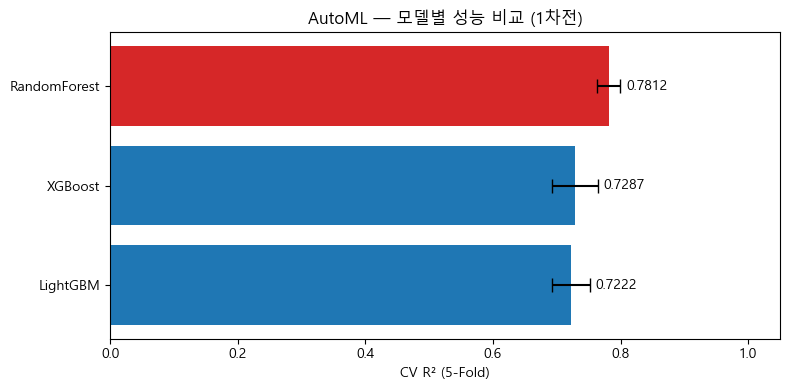

In [7]:
import optuna
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("🔥 1차전: 회귀 모델 3대장 성능 테스트 시작!")
print("=" * 50)

models = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(random_state=42, verbosity=0),
    'LightGBM':     LGBMRegressor(random_state=42, verbose=-1),
}

best_model_name = ""
best_cv_score   = -float('inf')
automl_results  = []

for name, model in models.items():
    scores   = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    mean_r2  = scores.mean()
    std_r2   = scores.std()
    automl_results.append({'Model': name, 'CV_R2_mean': round(mean_r2, 4),
                           'CV_R2_std': round(std_r2, 4)})
    print(f"  [{name:<15}] 평균 R²: {mean_r2:.4f}  (±{std_r2:.4f})")

    if mean_r2 > best_cv_score:
        best_cv_score   = mean_r2
        best_model_name = name

print(f"\n🏆 1차전 우승 모델: {best_model_name}  (R²: {best_cv_score:.4f})")
print("=" * 50)

# 시각화
automl_df = pd.DataFrame(automl_results).sort_values('CV_R2_mean', ascending=False)
colors = ['#d62728' if m == best_model_name else '#1f77b4' for m in automl_df['Model']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(automl_df['Model'][::-1], automl_df['CV_R2_mean'][::-1],
               xerr=automl_df['CV_R2_std'][::-1], color=colors[::-1],
               capsize=5, error_kw={'elinewidth': 1.5})
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlabel('CV R² (5-Fold)')
ax.set_title('AutoML — 모델별 성능 비교 (1차전)')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()


# 06. Optuna 하이퍼파라미터 튜닝 (2차전)

- 1차전 우승 모델에 맞는 탐색 공간을 자동 분기하여 튜닝
- **방향**: R² 최대화 (maximize), **30 trials**
- 최적 파라미터로 최종 모델 재학습 후 Test 성능 평가 (3차전)

In [8]:
print(f"🔥 2차전: 우승 모델({best_model_name}) 맞춤형 Optuna 튜닝 시작!")

def objective(trial):
    if best_model_name == 'LightGBM':
        params = {
            'n_estimators':  trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'max_depth':     trial.suggest_int('max_depth', 3, 12),
            'num_leaves':    trial.suggest_int('num_leaves', 20, 100),
            'random_state': 42, 'verbose': -1
        }
        model = LGBMRegressor(**params)
    elif best_model_name == 'XGBoost':
        params = {
            'n_estimators':  trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'max_depth':     trial.suggest_int('max_depth', 3, 12),
            'random_state': 42, 'verbosity': 0
        }
        model = XGBRegressor(**params)
    else:  # RandomForest
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
            'max_depth':         trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
            'random_state': 42
        }
        model = RandomForestRegressor(**params, n_jobs=-1)

    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n🎯 Optuna 튜닝 완료!")
print(f"   최적 CV R²    : {study.best_value:.4f}")
print(f"   최적 파라미터 : {study.best_params}")
print("=" * 50)


🔥 2차전: 우승 모델(RandomForest) 맞춤형 Optuna 튜닝 시작!


  0%|          | 0/30 [00:00<?, ?it/s]


🎯 Optuna 튜닝 완료!
   최적 CV R²    : 0.7832
   최적 파라미터 : {'n_estimators': 228, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [9]:
# ── 3차전: 최적 파라미터로 최종 모델 학습 & 평가 ────────
print(f"🔥 3차전: 튜닝된 최종 모델로 Test 데이터 예측 (진짜 수능!)")

if best_model_name == 'LightGBM':
    final_model = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
elif best_model_name == 'XGBoost':
    final_model = XGBRegressor(**study.best_params, random_state=42, verbosity=0)
else:
    final_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)

final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

final_r2   = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"\n{'='*50}")
print(f"📊 최종 모델 ({best_model_name} + Optuna) 성능")
print(f"   ✅ Test R²   : {final_r2:.4f}")
print(f"   ✅ Test RMSE : {final_rmse:.4f}")
print(f"{'='*50}")


🔥 3차전: 튜닝된 최종 모델로 Test 데이터 예측 (진짜 수능!)

📊 최종 모델 (RandomForest + Optuna) 성능
   ✅ Test R²   : 0.7381
   ✅ Test RMSE : 10.2728


# 07. Feature Importance & SHAP

## 7-1. Feature Importance (Elbow 분석)
- 변수별 중요도 + 엘보우 포인트 시각화
- 중요도 급감 지점 이후 변수 = 클러스터링 선택에서 참고

## 7-2. SHAP Value
- 각 변수가 예대마진 예측에 실제로 어떤 방향/크기로 기여하는지 확인
- Feature Importance와 교차 검증 → 최종 클러스터링 가중치 확정

🔻 변수별 중요도 및 하락폭:
 Feature  Importance      Drop
  여신한도금액    0.429163  0.000000
 총디지털거래액    0.187682 -0.241481
   총예금좌수    0.179406 -0.008276
총오프라인거래액    0.075146 -0.104260
   총카드소비    0.055024 -0.020122
   총외환실적    0.044669 -0.010355
자동이체거래건수    0.028910 -0.015760


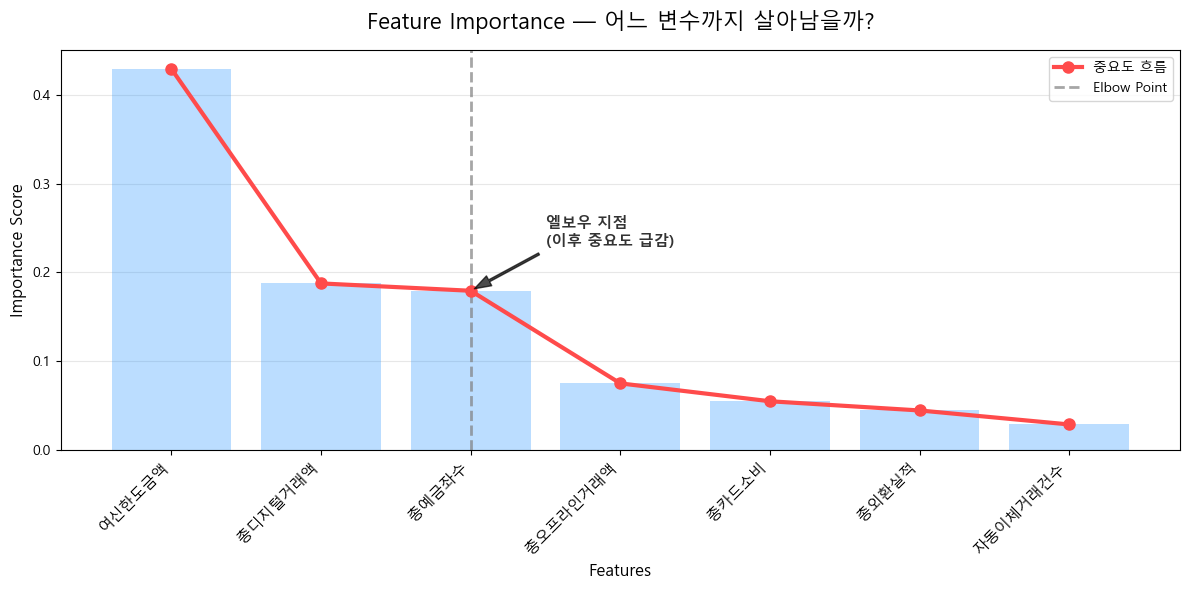


📌 클러스터링 가중치(importance_weights): {'여신한도금액': 0.4291631074574961, '총디지털거래액': 0.18768221788059278, '총예금좌수': 0.17940580284709856, '총오프라인거래액': 0.07514614238898674, '총카드소비': 0.0550239852531015, '총외환실적': 0.04466919800271464, '자동이체거래건수': 0.028909546170009737}


In [10]:
# ── 7-1. Feature Importance ──────────────────────────
importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature':    selected_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# 중요도 하락폭(Elbow) 계산
feature_importance_df['Drop'] = feature_importance_df['Importance'].diff().fillna(0)

print("🔻 변수별 중요도 및 하락폭:")
print(feature_importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(12, 6))

# 꺾은선 그래프 (Elbow 스타일)
plt.plot(feature_importance_df['Feature'], feature_importance_df['Importance'],
         marker='o', linestyle='-', color='#FF4B4B', linewidth=3, markersize=8, zorder=3, label='중요도 흐름')

# 배경 막대
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'],
        alpha=0.3, color='dodgerblue', zorder=2)

# 엘보우 포인트 강조 (index 2: 총예금좌수 기준)
elbow_idx   = 2
elbow_y_val = feature_importance_df['Importance'].iloc[elbow_idx]
plt.axvline(x=elbow_idx, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Elbow Point')
plt.annotate('엘보우 지점\n(이후 중요도 급감)',
             xy=(elbow_idx, elbow_y_val),
             xytext=(elbow_idx + 0.5, elbow_y_val + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, alpha=0.7),
             fontsize=11, fontweight='bold', color='#333333')

plt.title('Feature Importance — 어느 변수까지 살아남을까?', fontsize=16, pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 클러스터링 가중치 저장
importance_weights = dict(zip(feature_importance_df['Feature'], feature_importance_df['Importance']))
print("\n📌 클러스터링 가중치(importance_weights):", importance_weights)


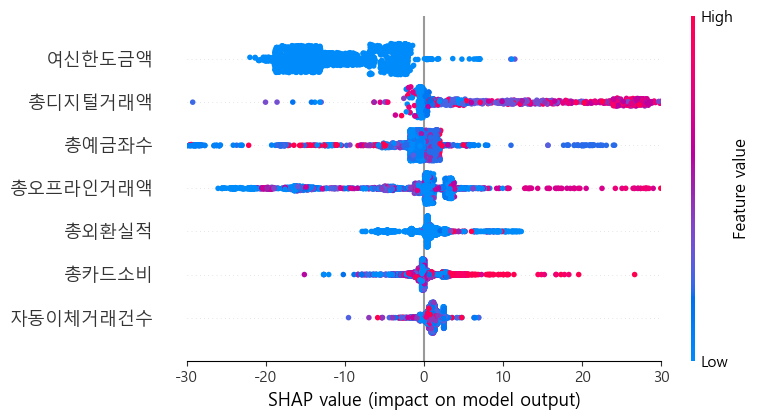

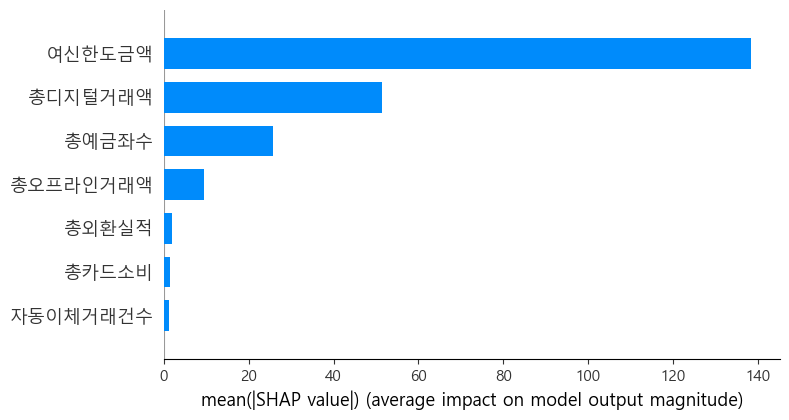

In [11]:
# ── 7-2. SHAP Value ──────────────────────────────────
import shap

explainer   = shap.TreeExplainer(final_model)
X_sample    = X_test.sample(n=min(3000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# Beeswarm (dot) plot
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.xlim(-30, 30)
plt.tight_layout()
plt.show()

# Bar plot (평균 절대 중요도)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()


🎯 '예대마진'과 피처 간 상관계수 랭킹


,예대마진
예대마진,1.000000
총외환실적,0.255097
여신한도금액,0.212114
총오프라인거래액,0.200685
총디지털거래액,0.159663
자동이체거래건수,0.144567
총카드소비,0.090499
총예금좌수,0.040392


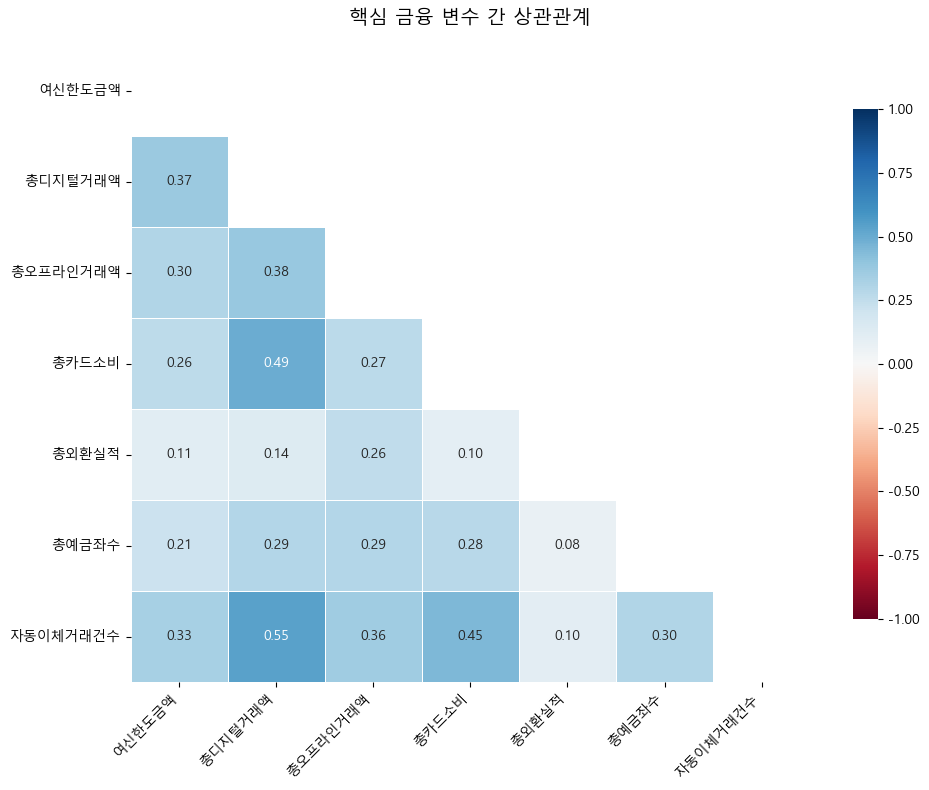

In [12]:
# ── 예대마진과 피처 간 상관계수 분석 ────────────────────
df_corr = X_train.copy()
df_corr['예대마진'] = y_train.values

target_corr = df_corr.corr()[['예대마진']].sort_values('예대마진', ascending=False)
print("🎯 '예대마진'과 피처 간 상관계수 랭킹")
print("=" * 40)
display(target_corr)

# 히트맵
corr_matrix = X_train[selected_features].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdBu', vmin=-1, vmax=1,
            cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='white')
plt.title('핵심 금융 변수 간 상관관계', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 08. 클러스터링 전처리 — z_ 변수 생성

- 대경 데이터 이상치 제거 (예대마진 ≥ −2500)
- 전체 selected_features 로그 변환 + StandardScaler → `z_` 접두사 변수
- 타 지역도 동일한 파이프라인으로 처리

In [13]:
# ── 대경 이상치 제거 ──────────────────────────────────
df_model = df_dg[df_dg['예대마진'] >= -2500].copy()

# ── 로그 변환 + z-score 스케일링 (대경) ────────────────
log_cols = [f'log_{c}' for c in selected_features]
z_cols   = [f'z_{c}'   for c in selected_features]

for col in selected_features:
    df_model[f'log_{col}'] = np.log1p(df_model[col])

scaler_dg = StandardScaler()
df_model[z_cols] = scaler_dg.fit_transform(df_model[log_cols])

margin_min_val           = df_model['예대마진'].min()
df_model['log_예대마진'] = np.log1p(df_model['예대마진'] - margin_min_val + 1)
df_model['z_예대마진']   = (df_model['log_예대마진'] - df_model['log_예대마진'].mean())                            / df_model['log_예대마진'].std()

# ── 타 지역 동일 전처리 ───────────────────────────────
df_clean_base     = df2.dropna(subset=['사업장_시도', '사업장_시군구']).copy()
df_others_cleaned = df_clean_base[
    ~df_clean_base['사업장_시도'].isin(['대구광역시', '경상북도'])
].copy()
df_others_cleaned = df_others_cleaned[df_others_cleaned['예대마진'].notnull()].copy()

for col in selected_features:
    df_others_cleaned[f'log_{col}'] = np.log1p(df_others_cleaned[col])

scaler_others = StandardScaler()
df_others_cleaned[z_cols] = scaler_others.fit_transform(df_others_cleaned[log_cols])

margin_min_others                   = df_others_cleaned['예대마진'].min()
df_others_cleaned['log_예대마진']   = np.log1p(df_others_cleaned['예대마진'] - margin_min_others + 1)
df_others_cleaned['z_예대마진']     = (
    df_others_cleaned['log_예대마진'] - df_others_cleaned['log_예대마진'].mean()
) / df_others_cleaned['log_예대마진'].std()

print(f"✅ 대경 df_model shape    : {df_model.shape}")
print(f"✅ 타 지역 shape          : {df_others_cleaned.shape}")


✅ 대경 df_model shape    : (269339, 80)
✅ 타 지역 shape          : (77960, 80)


# 09. 1st KMeans Clustering (대경 데이터)

- **목적**: 대구·경북 기업을 군집화 → **우량 법인 집단(성공 DNA)** 정의
- **사용 변수**: z_예대마진, z_총예금좌수, z_여신한도금액, z_총디지털거래액
- **K 선정**: Elbow + Silhouette → **K = 4** 채택
- **결과**: Cluster 2 = 예대마진·여신한도금액·디지털거래 최상위 **우량 집단**

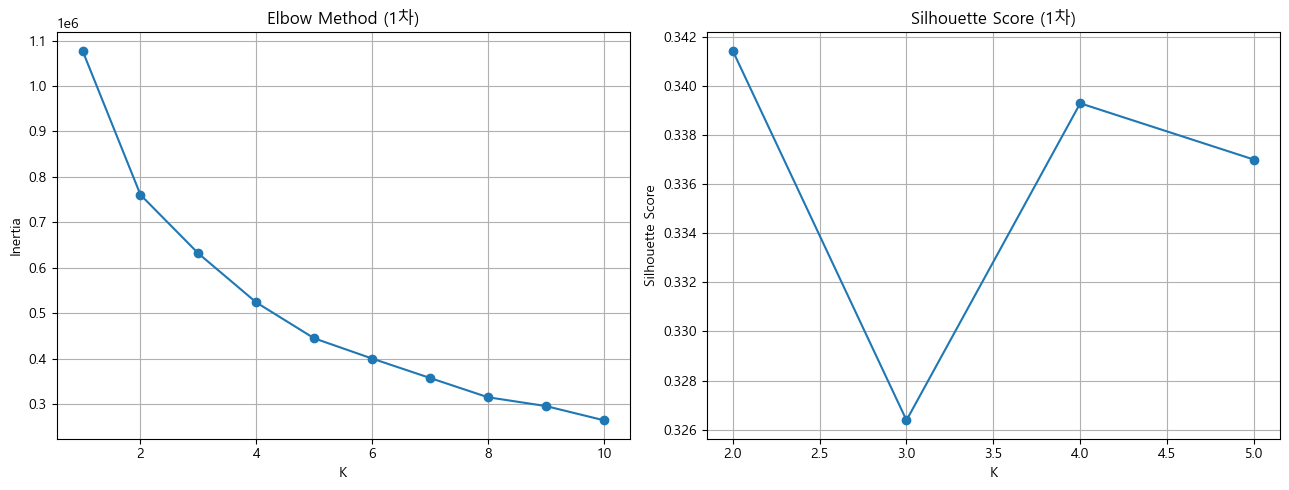

최적 K (Silhouette): 2  → 최종 K=4 채택


In [14]:
target_features = ['z_예대마진', 'z_총예금좌수', 'z_여신한도금액', 'z_총디지털거래액']
X_clust1 = df_model[target_features].copy()

# ── Elbow ────────────────────────────────────────────
inertias, K_range = [], range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_clust1).inertia_)

# ── Silhouette ───────────────────────────────────────
X1_s, sil_scores, K_sil = X_clust1.sample(frac=0.1, random_state=42), [], range(2, 6)
for k in K_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    sil_scores.append(silhouette_score(X1_s, km.fit_predict(X1_s)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertias, marker='o'); axes[0].set_title('Elbow Method (1차)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].grid(True)
axes[1].plot(K_sil, sil_scores, marker='o'); axes[1].set_title('Silhouette Score (1차)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score'); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f"최적 K (Silhouette): {K_sil[np.argmax(sil_scores)]}  → 최종 K=4 채택")


In [15]:
# ── 1차 클러스터링 적용 (K=4) ────────────────────────
kmeans1 = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_model['cluster'] = kmeans1.fit_predict(X_clust1)

print("📊 클러스터별 데이터 수:")
print(df_model['cluster'].value_counts().sort_index())

# 클러스터별 프로파일링
profile_features = ['예대마진', '총예금좌수', '여신한도금액', '총디지털거래액',
                    '총오프라인거래액', '총자산', '총외환실적', '총카드소비']
print("\n===== 클러스터별 핵심 지표 요약 =====")
display(df_model.groupby('cluster')[profile_features].agg(['mean', 'median']).round(2))


📊 클러스터별 데이터 수:
cluster
0    47357
1    68332
2    70825
3    82825
Name: count, dtype: int64

===== 클러스터별 핵심 지표 요약 =====


예대마진         총예금좌수          여신한도금액        총디지털거래액        총오프라인거래액  \
          mean median   mean median     mean median    mean median     mean   
cluster                                                                       
0         2.61   0.81  12.33    8.0   557.87  100.0  752.55  181.7   322.82   
1         4.39   1.12   2.74    2.0     0.26    0.0  232.03   87.6    51.08   
2        11.26   2.62   3.43    4.0  1488.09  290.0  596.51  157.0   337.70   
3         2.25   0.46   2.31    2.0    27.61    0.0    1.39    0.0    16.55   

                    총자산         총외환실적        총카드소비         
        median     mean  median  mean median  mean median  
cluster                                                    
0          2.7  1611.66  500.00  0.04    0.0  9.57    4.0  
1          0.0  1229.00  410.00  0.01    0.0  4.78    1.9  
2          1.0  2916.88  790.28  0.05    0.0  6.83    2.9  
3          0.0   572.26  132.00  0.00    0.0  1.14    0.0

# 10. 2nd KMeans Clustering (대경 우량집단 + 전국)

- **목적**: 대경 우량집단(Cluster 2) DNA를 타 지역과 통합하여 전국 단위 패턴 유사도 분석 준비
- **통합**: 대경 우량집단(Cluster 2) + 전국 타 지역 정제 데이터
- **K 선정**: Elbow + Silhouette → **K = 3** 채택
- **결과**: Final_Cluster 2 = 대경 우량 DNA가 압도적으로 밀집된 핵심 군집

In [16]:
# ── 대경 우량집단(Cluster 2) + 타 지역 통합 ─────────
df_dg_excellent = df_model[df_model['cluster'] == 2].copy()
df_final_input  = pd.concat([df_dg_excellent, df_others_cleaned], axis=0).reset_index(drop=True)

print(f"통합 데이터 shape: {df_final_input.shape}")
print("\n지역별 분포:")
print(df_final_input['사업장_시도'].value_counts())


통합 데이터 shape: (148785, 81)

지역별 분포:
사업장_시도
대구광역시      39190
경상북도       31635
미상         16993
서울특별시      16477
부산광역시      16172
경상남도       10845
경기도         9734
울산광역시       3245
인천광역시       2953
대전광역시       1218
세종특별자치시      215
광주광역시         77
충청남도          31
Name: count, dtype: int64


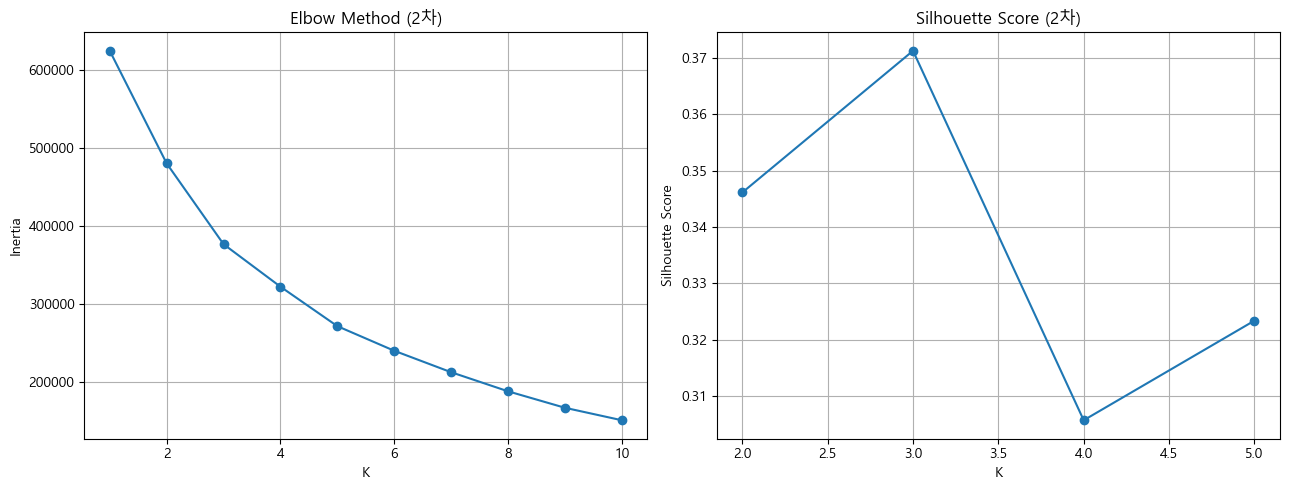

최적 K (Silhouette): 3  → 최종 K=3 채택


In [17]:
X_clust2 = df_final_input[target_features].copy()

inertias2, K_range2 = [], range(1, 11)
for k in K_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias2.append(km.fit(X_clust2).inertia_)

X2_s, sil_scores2, K_sil2 = X_clust2.sample(frac=0.5, random_state=42), [], range(2, 6)
for k in K_sil2:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    sil_scores2.append(silhouette_score(X2_s, km.fit_predict(X2_s)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range2, inertias2, marker='o'); axes[0].set_title('Elbow Method (2차)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].grid(True)
axes[1].plot(K_sil2, sil_scores2, marker='o'); axes[1].set_title('Silhouette Score (2차)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score'); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f"최적 K (Silhouette): {K_sil2[np.argmax(sil_scores2)]}  → 최종 K=3 채택")


In [18]:
# ── 2차 클러스터링 적용 (K=3) ────────────────────────
kmeans2 = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_final_input['Final_Cluster'] = kmeans2.fit_predict(X_clust2)

print("--- 2차 클러스터링 완료 ---")
print(f"최종 분석 데이터: {len(df_final_input)}건")
print("\n[지역별 최종 클러스터 분포]")
display(df_final_input.groupby(['사업장_시도', 'Final_Cluster']).size().unstack(fill_value=0))
print("\n클러스터별 데이터 수:")
print(df_final_input['Final_Cluster'].value_counts())


--- 2차 클러스터링 완료 ---
최종 분석 데이터: 148785건

[지역별 최종 클러스터 분포]


Final_Cluster,0,1,2
사업장_시도,,,
경기도,2587,7147,0
경상남도,3296,7549,0
경상북도,30838,158,639
광주광역시,21,56,0
대구광역시,38072,194,924
대전광역시,493,725,0
미상,7540,9453,0
부산광역시,5827,10345,0
서울특별시,5805,10672,0



클러스터별 데이터 수:
Final_Cluster
0    96690
1    50532
2     1563
Name: count, dtype: int64


In [19]:
# ── 클러스터별 상세 프로파일링 ───────────────────────
extended_features = ['예대마진', '총예금좌수', '여신한도금액', '총디지털거래액',
                     '총오프라인거래액', '총자산', '전체거래액', '총외환실적', '총카드소비']

print("===== [ 클러스터별 상세 프로파일링 ] =====")
for feature in extended_features:
    stats_df = df_final_input.groupby('Final_Cluster')[feature].agg(['mean','median','min','max']).reset_index()
    counts   = df_final_input.groupby('Final_Cluster').size().reset_index(name='count')
    counts['ratio(%)'] = (counts['count'] / len(df_final_input) * 100).round(1)
    print(f"\n📊 [{feature}]")
    print(pd.merge(stats_df, counts, on='Final_Cluster').round(2).to_string(index=False))


===== [ 클러스터별 상세 프로파일링 ] =====

📊 [예대마진]
 Final_Cluster   mean  median       min     max  count  ratio(%)
             0   5.34    2.35 -13837.55  634.20  96690      65.0
             1   4.96    2.25 -19204.15  418.56  50532      34.0
             2 191.70  137.68     75.92 1049.01   1563       1.1

📊 [총예금좌수]
 Final_Cluster  mean  median  min  max  count  ratio(%)
             0  3.48     4.0  0.0 70.5  96690      65.0
             1  2.14     1.0  0.0 63.0  50532      34.0
             2  8.70     6.0  0.0 57.0   1563       1.1

📊 [여신한도금액]
 Final_Cluster     mean  median  min      max  count  ratio(%)
             0  1647.55   300.0  0.0 300000.0  96690      65.0
             1     2.49     0.0  0.0   2000.0  50532      34.0
             2 23250.35 15000.0  0.0 150000.0   1563       1.1

📊 [총디지털거래액]
 Final_Cluster    mean  median  min        max  count  ratio(%)
             0 2245.63   131.0  0.0 2162000.00  96690      65.0
             1  101.80     0.0  0.0   14000.00  50532      

# 11. Cosine Similarity Analysis

- **목적**: Final_Cluster 2(대경 우량 DNA 밀집 군집) 기준, 타 지역 금융 패턴 방향 유사도 측정
- **방법**: 코사인 유사도 (1에 가까울수록 금융 패턴 구조가 유사)
- **단계**: 시도(광역) → 시군구(기초) 순으로 세분화
- **결과**: 유사도 상위 지역 = iM뱅크 전략 거점 후보 확정

In [41]:
# ── 대경 + 타지역이 함께 포함된 최종 클러스터 자동 선택 ─────────────────
cos_features = [c for c in [
    'z_예대마진', 'z_총예금좌수', 'z_여신한도금액', 'z_총디지털거래액',
    'z_총오프라인거래액', 'z_자동이체거래건수', 'z_총외환실적', 'z_총카드소비'
] if c in df_final_input.columns]

# 대경 여부 컬럼 생성
df_final_input['지역_통합'] = df_final_input['사업장_시도'].apply(
    lambda x: '대경' if x in ['대구광역시', '경상북도'] else x
)

# 입지 후보로 해석할 수 없는 '미상' 제외
df_final_valid = df_final_input[df_final_input['지역_통합'] != '미상'].copy()

# 클러스터별 대경/타지역 수 확인
cluster_summary = pd.DataFrame({
    '대경수': df_final_valid[df_final_valid['지역_통합'] == '대경']
        .groupby('Final_Cluster')
        .size(),
    '타지역수': df_final_valid[df_final_valid['지역_통합'] != '대경']
        .groupby('Final_Cluster')
        .size()
}).fillna(0).astype(int)

cluster_summary['전체수'] = cluster_summary['대경수'] + cluster_summary['타지역수']
cluster_summary['대경비율'] = cluster_summary['대경수'] / cluster_summary['전체수']

print("=== 클러스터별 대경/타지역 구성 ===")
display(cluster_summary)

# 대경과 타지역이 모두 있는 클러스터만 후보로 사용
valid_clusters = cluster_summary[
    (cluster_summary['대경수'] > 0) &
    (cluster_summary['타지역수'] > 0)
].copy()

if valid_clusters.empty:
    raise ValueError("대경과 타지역이 함께 포함된 클러스터가 없습니다. 2차 클러스터링 조건을 다시 확인해야 합니다.")

# 대경 비율이 가장 높은 클러스터 선택
target_cluster = valid_clusters['대경비율'].idxmax()

print(f"선택된 최종 클러스터: {target_cluster}")

# 최종 분석 클러스터 생성
df_c3 = df_final_valid[df_final_valid['Final_Cluster'] == target_cluster].copy()

region_stats = df_c3.groupby('지역_통합')[cos_features].median()

print(f"분석 변수 {len(cos_features)}개: {cos_features}")
print(f"\n선택 클러스터 데이터 수: {len(df_c3)}건")
print("\n지역별 분포:")
print(df_c3['지역_통합'].value_counts())

=== 클러스터별 대경/타지역 구성 ===


,대경수,타지역수,전체수,대경비율
Final_Cluster,,,,
0,68910,20240,89150,0.772967
1,352,40727,41079,0.008569
2,1563,0,1563,1.000000


선택된 최종 클러스터: 0
분석 변수 8개: ['z_예대마진', 'z_총예금좌수', 'z_여신한도금액', 'z_총디지털거래액', 'z_총오프라인거래액', 'z_자동이체거래건수', 'z_총외환실적', 'z_총카드소비']

선택 클러스터 데이터 수: 89150건

지역별 분포:
지역_통합
대경         68910
부산광역시       5827
서울특별시       5805
경상남도        3296
경기도         2587
울산광역시       1188
인천광역시        979
대전광역시        493
세종특별자치시       40
광주광역시         21
충청남도           4
Name: count, dtype: int64


In [42]:
# ── 시도 단위 코사인 유사도 계산 ────────────────────
daegyeong_pattern = region_stats.loc['대경'].values.reshape(1, -1)
cosine_list = []

for region in region_stats.index:
    if region == '대경': continue
    sim        = cosine_similarity(daegyeong_pattern,
                                   region_stats.loc[region].values.reshape(1, -1))[0][0]
    corp_count = len(df_c3[df_c3['지역_통합'] == region])
    cosine_list.append({'지역': region, 'Cosine 유사도': round(sim, 4), '법인수(Cluster2)': corp_count})

cosine_ranking = pd.DataFrame(cosine_list).sort_values('Cosine 유사도', ascending=False).reset_index(drop=True)
print("🏆 [코사인 유사도] 대경 G2와 가장 패턴이 유사한 시도 TOP 5")
print("※ 1에 가까울수록 금융 패턴(구조)이 유사")
print("=" * 55)
display(cosine_ranking.head(5))


🏆 [코사인 유사도] 대경 G2와 가장 패턴이 유사한 시도 TOP 5
※ 1에 가까울수록 금융 패턴(구조)이 유사


,지역,Cosine 유사도,법인수(Cluster2)
0,부산광역시,0.9750,5827
1,경상남도,0.9721,3296
2,울산광역시,0.9552,1188
3,광주광역시,0.8381,21
4,대전광역시,0.7425,493


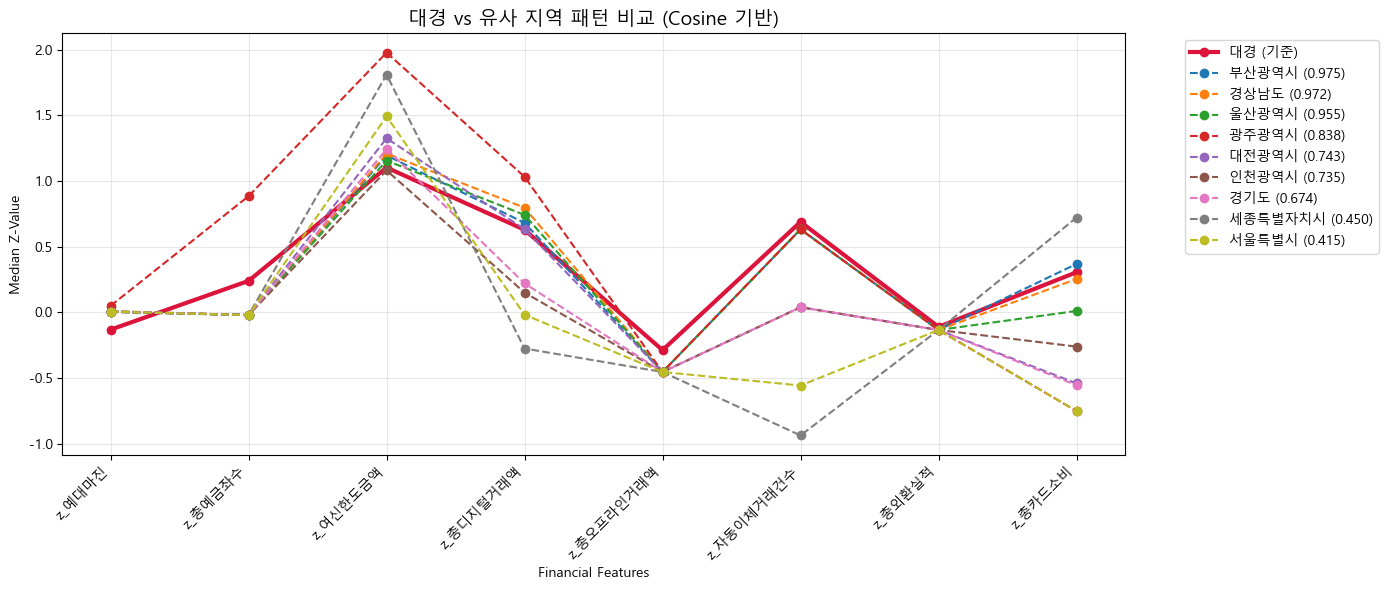

In [43]:
# ── 시도 패턴 비교 시각화 ────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(cos_features, region_stats.loc['대경'],
         marker='o', linewidth=3, color='crimson', label='대경 (기준)')

for region in cosine_ranking.head(9)['지역']:
    sim_val = cosine_ranking.set_index('지역').loc[region, 'Cosine 유사도']
    plt.plot(cos_features, region_stats.loc[region],
             marker='o', linestyle='--',
             label=f"{region} ({sim_val:.3f})")

plt.title("대경 vs 유사 지역 패턴 비교 (Cosine 기반)", fontsize=14)
plt.xlabel("Financial Features"); plt.ylabel("Median Z-Value")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [44]:
# ── 시군구 단위 코사인 유사도 계산 ──────────────────
sigungu_stats   = df_c3.groupby('사업장_시군구')[cos_features].median()
sigungu_to_sido = df_c3.groupby('사업장_시군구')['사업장_시도'].first().to_dict()

cosine_list_sg = []
for sigungu in sigungu_stats.index:
    sido = sigungu_to_sido[sigungu]
    if sido in ['대구광역시', '경상북도']: continue
    sim        = cosine_similarity(daegyeong_pattern,
                                   sigungu_stats.loc[sigungu].values.reshape(1, -1))[0][0]
    corp_count = len(df_c3[df_c3['사업장_시군구'] == sigungu])
    cosine_list_sg.append({'시도': sido, '시군구': sigungu,
                           'Cosine 유사도': round(sim, 4), '법인수': corp_count})

sigungu_ranking = (pd.DataFrame(cosine_list_sg)
                     .sort_values('Cosine 유사도', ascending=False)
                     .reset_index(drop=True))

print("🏆 [시군구] 대경 DNA와 가장 유사한 지역 TOP 10")
print("=" * 60)
display(sigungu_ranking.head(10))


🏆 [시군구] 대경 DNA와 가장 유사한 지역 TOP 10


,시도,시군구,Cosine 유사도,법인수
0,부산광역시,사상구,0.9761,1527
1,경상남도,김해시,0.9726,1116
2,부산광역시,강서구,0.9724,2028
3,경기도,안성시,0.9700,13
4,경상남도,창원시 의창구,0.9686,211
5,경상남도,창원시 진해구,0.9675,308
6,경상남도,양산시,0.9637,743
7,부산광역시,부산진구,0.9614,445
8,경기도,화성시,0.9614,798
9,경상남도,창녕군,0.9597,627


In [45]:
# ── 유사도 df_c3에 병합 ──────────────────────────────
sido_sim_dict    = dict(zip(cosine_ranking['지역'], cosine_ranking['Cosine 유사도']))
sigungu_sim_dict = dict(zip(sigungu_ranking['시군구'], sigungu_ranking['Cosine 유사도']))

df_c3['유사도시도']   = df_c3['지역_통합'].map(sido_sim_dict)
df_c3['유사도시군구'] = df_c3['사업장_시군구'].map(sigungu_sim_dict)
df_c3.loc[df_c3['지역_통합'] == '대경', ['유사도시도', '유사도시군구']] = 1.0
df_c3 = df_c3.dropna(subset=['유사도시도', '유사도시군구'])

print(f"✅ 유사도 병합 완료 | df_c3 shape: {df_c3.shape}")


✅ 유사도 병합 완료 | df_c3 shape: (85697, 85)


# 12. Final Insight

## 분석 결과 요약

| 순위 | 지역 | Cosine 유사도 | 전략적 의미 |
|:----:|------|:-----------:|------------|
| 1 | 부산광역시 | 0.9750 | 제조업 기반, 운전자금 수요 높음 → 즉각 공략 가능 |
| 2 | 경상남도   | 0.9721 | 대경 인접, 유사 산업 생태계 |
| 3 | 울산광역시 | 0.9552 | 중화학·제조 집적지, 기업금융 수요 충분 |
| 4 | 광주광역시 | 0.8381 | 디지털 채널 성장세, 잠재력 존재 |
| 5 | 대전광역시 | 0.7425 | 연구개발·기술 기반 중소기업이 밀집한 충청권 기업금융 후보지 |

## 인사이트 및 전략 로드맵

**Phase 1 — 즉각 공략 (부산·경남·울산)**
- 대경 우량 DNA(제조업·운전자금·디지털 채널)와 구조적으로 가장 유사
- 대형 지점 신설 + 기업금융 전문인력(PRM) 전진 배치

**Phase 2 — 중기 진출 (광주·대전)**
- 광주: 제조업·중소기업 기반의 기업금융 수요 확인 지역
- 대전: 연구개발·기술 기반 중소기업이 밀집한 충청권 후보지
- 소형 거점 또는 기업금융 전담 출장소 형태의 효율적 진출 검토

**핵심 영업 전략**

| 구분 | 내용 |
|------|------|
| 여신 | 운전자금 대출, 보증 연계 대출, 기술기업 성장자금 지원 |
| 수신 | 급여이체·결제계좌 선점, 기업 운영자금 예치 유도 |
| 채널 | 디지털 채널 활용 기업 대상 비대면 온보딩 강화 |
| 관계 | 자동이체·결제계좌 확대를 통한 장기 주거래 고객화 |

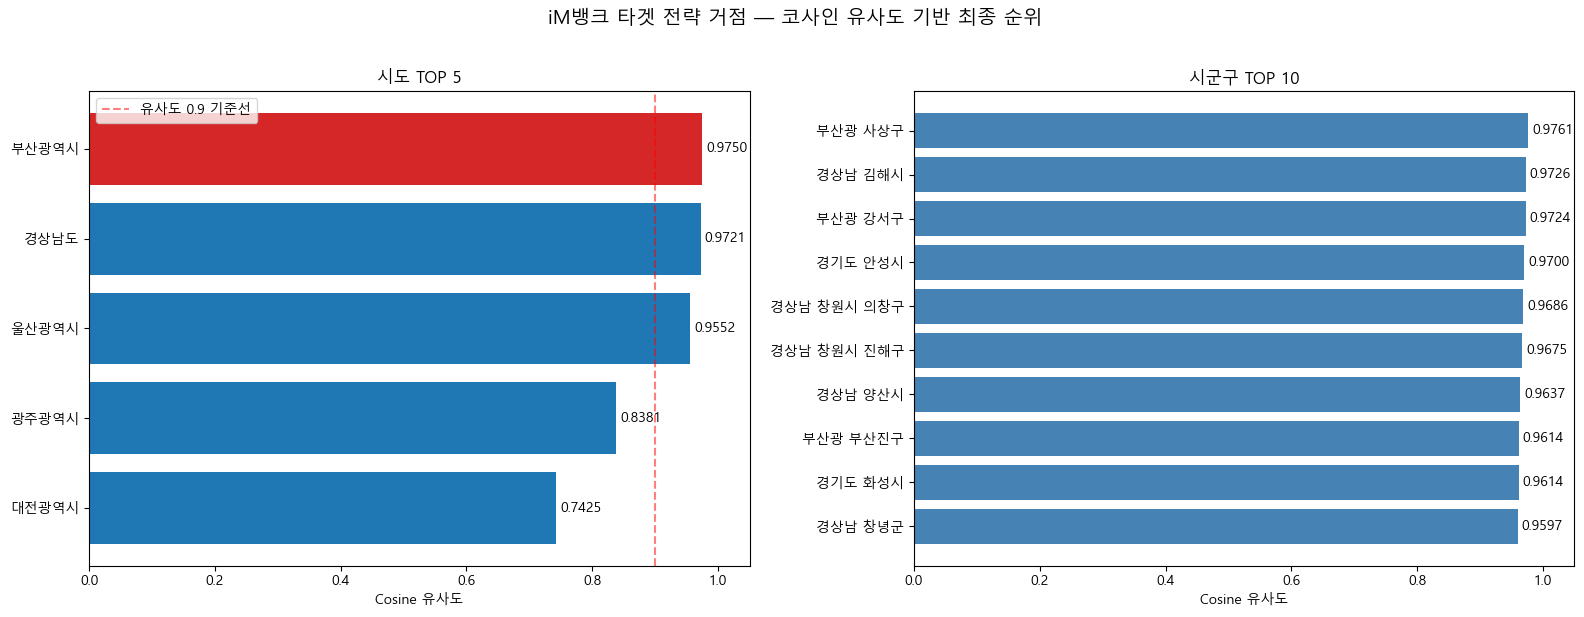


✅ 전체 분석 완료
📌 최우선 전략 거점 (시도 Top 5)
   지역  Cosine 유사도  법인수(Cluster2)
부산광역시      0.9750           5827
 경상남도      0.9721           3296
울산광역시      0.9552           1188
광주광역시      0.8381             21
대전광역시      0.7425            493

📌 최우선 전략 거점 (시군구 Top 5)
   시도     시군구  Cosine 유사도  법인수
부산광역시     사상구      0.9761 1527
 경상남도     김해시      0.9726 1116
부산광역시     강서구      0.9724 2028
  경기도     안성시      0.9700   13
 경상남도 창원시 의창구      0.9686  211


In [47]:
# ── 최종 TOP 지역 시각화 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시도 Top 5
top5   = cosine_ranking.head(5)
colors = ['#d62728' if i == 0 else '#1f77b4' for i in range(len(top5))]
bars   = axes[0].barh(top5['지역'][::-1], top5['Cosine 유사도'][::-1], color=colors[::-1])
axes[0].bar_label(bars, fmt='%.4f', padding=3)
axes[0].set_xlim(0, 1.05)
axes[0].axvline(x=0.9, color='red', linestyle='--', alpha=0.5, label='유사도 0.9 기준선')
axes[0].set_xlabel('Cosine 유사도'); axes[0].set_title('시도 TOP 5')
axes[0].legend()

# 시군구 Top 10
top10 = sigungu_ranking.head(10).copy()
top10['label'] = top10['시도'].str[:3] + ' ' + top10['시군구']
bars2 = axes[1].barh(top10['label'][::-1], top10['Cosine 유사도'][::-1], color='steelblue')
axes[1].bar_label(bars2, fmt='%.4f', padding=3)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel('Cosine 유사도'); axes[1].set_title('시군구 TOP 10')

plt.suptitle('iM뱅크 타겟 전략 거점 — 코사인 유사도 기반 최종 순위', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\n✅ 전체 분석 완료")
print("=" * 60)
print("📌 최우선 전략 거점 (시도 Top 5)")
print(cosine_ranking.head(5).to_string(index=False))
print("\n📌 최우선 전략 거점 (시군구 Top 5)")
print(sigungu_ranking.head(5).to_string(index=False))
